In [1]:
!pip install -q sentence-transformers seaborn matplotlib pandas scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 10 sentences across exactly 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    "Virat Kohli scored a century in the final match.",
    "The bowler delivered a perfect yorker to dismiss the batsman.",
    "India won the cricket match by chasing the target in the last over.",
    "The captain set an aggressive field during the powerplay.",
    "I added garlic and butter to the pan before cooking the pasta.",
    "The chef baked a chocolate cake at 180 degrees for thirty minutes.",
    "Fresh vegetables and spices made the curry taste much better.",
    "The company installed a firewall to block unauthorized network access.",
    "Phishing emails can trick users into revealing their passwords.",
    "Multi-factor authentication improves account security against hackers."
]

labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cybersecurity 1", "Cybersecurity 2", "Cybersecurity 3"
]

print("Total sentences:", len(sentences))
for i, sentence in enumerate(sentences, start=1):
    print(f"{i}. {sentence}")

Total sentences: 10
1. Virat Kohli scored a century in the final match.
2. The bowler delivered a perfect yorker to dismiss the batsman.
3. India won the cricket match by chasing the target in the last over.
4. The captain set an aggressive field during the powerplay.
5. I added garlic and butter to the pan before cooking the pasta.
6. The chef baked a chocolate cake at 180 degrees for thirty minutes.
7. Fresh vegetables and spices made the curry taste much better.
8. The company installed a firewall to block unauthorized network access.
9. Phishing emails can trick users into revealing their passwords.
10. Multi-factor authentication improves account security against hackers.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

10x10 Cosine Similarity Matrix:


,Cricket 1,Cricket 2,Cricket 3,Cricket 4,Cooking 1,Cooking 2,Cooking 3,Cybersecurity 1,Cybersecurity 2,Cybersecurity 3
Cricket 1,1.000,0.431,0.546,0.170,-0.061,0.165,0.187,-0.006,-0.002,0.069
Cricket 2,0.431,1.000,0.464,0.302,0.022,0.182,0.143,0.072,0.018,-0.004
Cricket 3,0.546,0.464,1.000,0.217,0.027,0.093,0.139,0.124,-0.028,-0.024
Cricket 4,0.170,0.302,0.217,1.000,-0.019,0.014,-0.023,0.103,-0.007,0.071
Cooking 1,-0.061,0.022,0.027,-0.019,1.000,0.205,0.223,0.195,0.019,0.033
Cooking 2,0.165,0.182,0.093,0.014,0.205,1.000,0.097,0.105,0.054,-0.004
Cooking 3,0.187,0.143,0.139,-0.023,0.223,0.097,1.000,0.009,0.034,0.094
Cybersecurity 1,-0.006,0.072,0.124,0.103,0.195,0.105,0.009,1.000,0.177,0.204
Cybersecurity 2,-0.002,0.018,-0.028,-0.007,0.019,0.054,0.034,0.177,1.000,0.507
Cybersecurity 3,0.069,-0.004,-0.024,0.071,0.033,-0.004,0.094,0.204,0.507,1.000


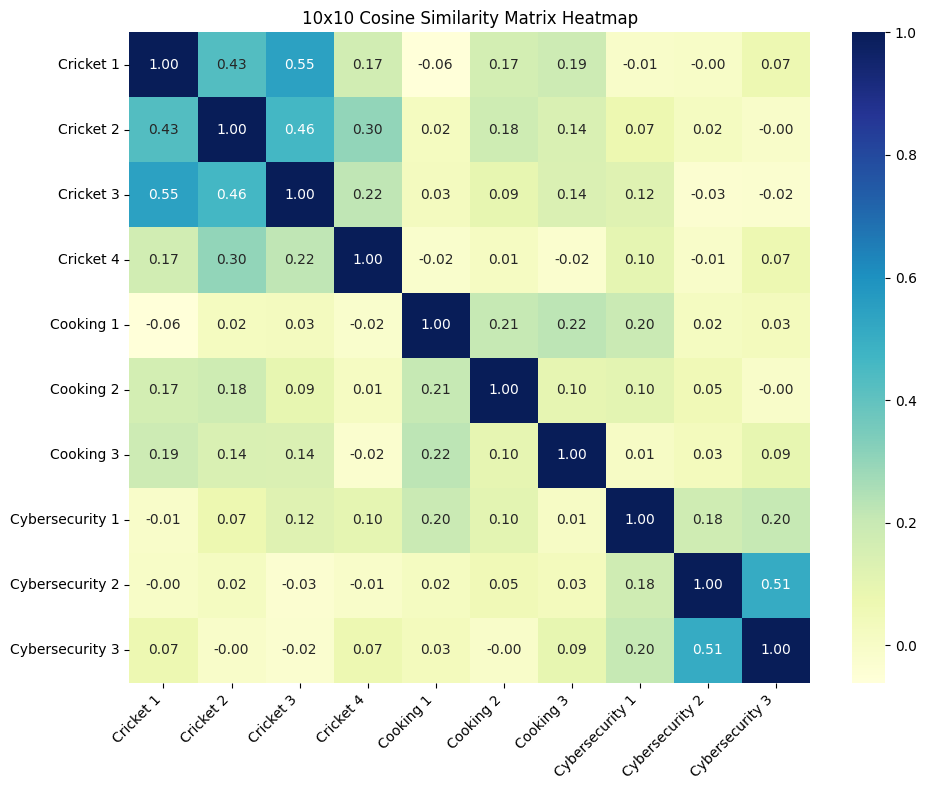

In [3]:
# Load the sentence-transformers model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(sentences)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Convert to DataFrame for display
similarity_df = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

print("10x10 Cosine Similarity Matrix:")
display(similarity_df.round(3))

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("10x10 Cosine Similarity Matrix Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# New query sentence
query_sentence = "The bowler took three wickets in one over"

# Generate embedding for the query
query_embedding = model.encode([query_sentence])

# Compute similarity between query and all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Create results DataFrame
result_df = pd.DataFrame({
    "Sentence": sentences,
    "Similarity Score": query_similarities
})

# Sort and get top 2
top_2 = result_df.sort_values(by="Similarity Score", ascending=False).head(2).reset_index(drop=True)

print("Query Sentence:")
print(query_sentence)
print("\nTop 2 Most Similar Sentences:")

for i, row in top_2.iterrows():
    print(f"{i+1}. {row['Sentence']}")
    print(f"   Similarity Score: {row['Similarity Score']:.6f}")

Query Sentence:
The bowler took three wickets in one over

Top 2 Most Similar Sentences:
1. The bowler delivered a perfect yorker to dismiss the batsman.
   Similarity Score: 0.595427
2. India won the cricket match by chasing the target in the last over.
   Similarity Score: 0.559743
